# Week1-2: Evaluating the likelihood on a grid
- Calculate the log(likelihood) for each pair of model parameters (mean(vr), dispersion(vr)) 
- Visualize the log(likelihood) on the 2D grid of (mean, dispersion) 

In [437]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%matplotlib inline

In [2]:
data_path = '../data/'

In [412]:
df = pd.read_csv(data_path+'Cas3_dg.csv')
df1 = pd.read_csv(data_path+'Cas3_dg_s1.csv')

df2 = df.sample(n=1)
print (df2['vr'])


198   -367.66
Name: vr, dtype: float64


Text(0.5, 0, 'Radial Velocity (km/s)')

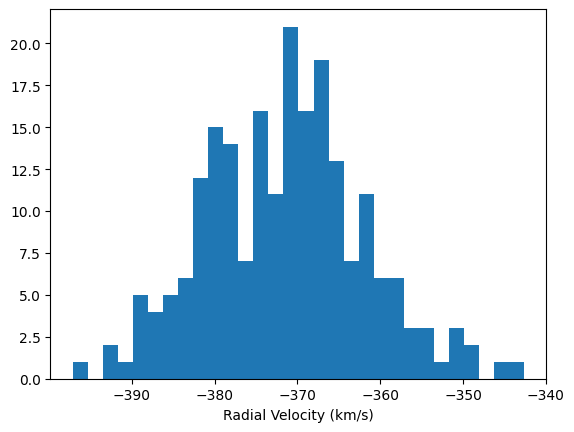

In [441]:
# Check the histogram of velocities of Cas3, we can estimate the range of mean (from -380 km/s to -360 km/s) and diserpsion (from 7 km/s to 12 km/s) by eye.
plt.figure()
plt.hist(df['vr'], bins=30);
plt.xlabel('Radial Velocity (km/s)')

In [413]:
# Now let's create a grid of 50x50 points in the range of -380 to -360 for mvr and 7 to 12 for dvr
# We increase the parameter range as the number of stars decreases 

mvr_grid = np.array(np.arange(-380, -360, .4))
dvr_grid = np.array(np.arange(5, 15, 0.1))

mvr_grid1 = np.array(np.arange(-420, -360, .4))
dvr_grid1 = np.array(np.arange(5, 20, 0.1))

mvr_grid2 = np.array(np.arange(-400, -330, .4))
dvr_grid2 = np.array(np.arange(1, 80, .2))

logL_grid = np.zeros((len(mvr_grid), len(dvr_grid)))
logL_grid1 = np.zeros((len(mvr_grid1), len(dvr_grid1)))
logL_grid2 = np.zeros((len(mvr_grid2), len(dvr_grid2)))


In [415]:
# for each pair of (mean(vr), dispersion(vr)), we define the following function to calculate the log(L) for all the stars in the dwarf galaxy Cas III
def log_Likelihood(mvr, dvr, vr_dg):
    
    logL = np.sum(np.log(1/(dvr * np.sqrt(2 * np.pi))) - ((vr_dg - mvr)**2) / (2 * dvr**2))

    return logL

In [416]:
# We now can calculate the log(L) for each gridding point
for i in range(logL_grid.shape[0]):
    for j in range(logL_grid.shape[1]):
        logL_grid[i, j] = log_Likelihood(mvr_grid[i], dvr_grid[j], df['vr'])

In [417]:
# We now can calculate the log(L) for each gridding point
for i in range(logL_grid1.shape[0]):
    for j in range(logL_grid1.shape[1]):
        logL_grid1[i, j] = log_Likelihood(mvr_grid1[i], dvr_grid1[j], df1['vr'])

In [418]:
# We now can calculate the log(L) for each gridding point
for i in range(logL_grid2.shape[0]):
    for j in range(logL_grid2.shape[1]):
        logL_grid2[i, j] = log_Likelihood(mvr_grid2[i], dvr_grid2[j], np.asarray(df2['vr']))

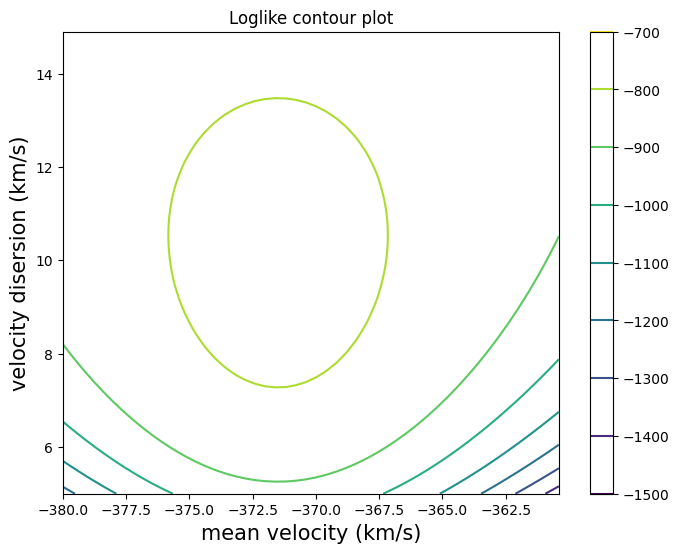

In [419]:
# Here comes to the visualizations!
# Note that when we plot in contour and imshow, the 2D array need to be inverted !!
# This is the contour plot of logL, whic does not make too much senses, let's plot contour plot of L next.

plt.figure(figsize=(8, 6))
contour = plt.contour(mvr_grid, dvr_grid, logL_grid.T)
plt.colorbar(contour)  # Add colorbar




plt.title('Loglike contour plot')
plt.xlabel('mean velocity (km/s)', fontsize=15)
plt.ylabel('velocity disersion (km/s)', fontsize=15)
plt.show()

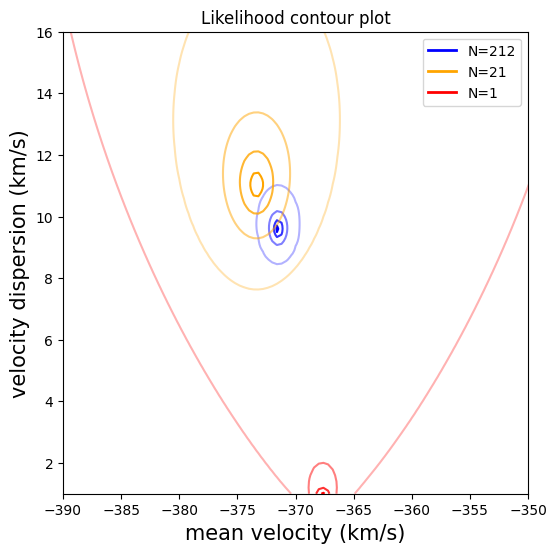

In [439]:
# This is the contour plot of Likelihood, we want it to be normalized to the maximum value
levels = np.array([0.025, 0.5, 0.84, 0.975])

alphas = [0.3, 0.5, 0.8, 1.0]

plt.figure(figsize=(6,6))
plt.contour(mvr_grid, dvr_grid, np.exp(logL_grid.T-np.max(logL_grid)), levels=levels, colors='blue', alpha=alphas)
plt.contour(mvr_grid1, dvr_grid1, np.exp(logL_grid1.T-np.max(logL_grid1)), levels=levels, colors='orange', alpha=alphas)
plt.contour(mvr_grid2, dvr_grid2, np.exp(logL_grid2.T-np.max(logL_grid2)), levels=levels, colors='red', alpha=alphas)




# Create legend
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='N=%i'%len(df)),
    Line2D([0], [0], color='orange', lw=2, label='N=%i'%len(df1)),
    Line2D([0], [0], color='red', lw=2, label='N=1')
]

plt.legend(handles=legend_elements)

plt.ylim(1, 16)
plt.xlim(-390, -350)

plt.title('Likelihood contour plot')
plt.xlabel('mean velocity (km/s)', fontsize=15)
plt.ylabel('velocity dispersion (km/s)', fontsize=15)
plt.show()

In [443]:
# Now let's add velocity uncertainties

def log_Likelihood_uncertainty(mvr, dvr, vr_dg, vr_dg_err):

    sigma = np.sqrt(dvr**2 + vr_dg_err**2)

    logL = np.sum(np.log(1/(sigma * np.sqrt(2 * np.pi))) - ((vr_dg - mvr)**2) / (2 * sigma**2))

    return logL 

In [444]:
logL_grid3 = np.zeros((len(mvr_grid), len(dvr_grid)))

# We now can calculate the log(L) for each gridding point
for i in range(logL_grid3.shape[0]):
    for j in range(logL_grid3.shape[1]):
        logL_grid3[i, j] = log_Likelihood_uncertainty(mvr_grid[i], dvr_grid[j], df['vr'],  df['e_vr'])

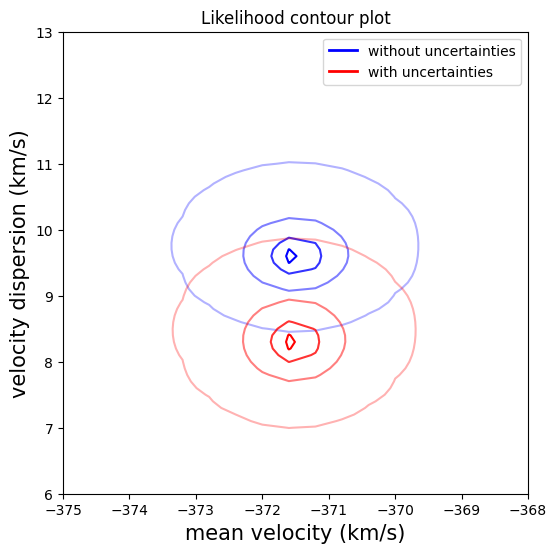

In [452]:
# This is the contour plot of Likelihood, we want it to be normalized to the maximum value
levels = np.array([0.025, 0.5, 0.84, 0.975])

alphas = [0.3, 0.5, 0.8, 1.0]

plt.figure(figsize=(6,6))
plt.contour(mvr_grid, dvr_grid, np.exp(logL_grid.T-np.max(logL_grid)), levels=levels, colors='blue', alpha=alphas)
plt.contour(mvr_grid, dvr_grid, np.exp(logL_grid3.T-np.max(logL_grid3)), levels=levels, colors='red', alpha=alphas)




# Create legend
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='without uncertainties'),
    Line2D([0], [0], color='red', lw=2, label='with uncertainties'),
]

plt.legend(handles=legend_elements)

plt.ylim(6, 13)
plt.xlim(-375, -368)

plt.title('Likelihood contour plot')
plt.xlabel('mean velocity (km/s)', fontsize=15)
plt.ylabel('velocity dispersion (km/s)', fontsize=15)
plt.show()